cluster_data/05jun/3.00/1.00
93


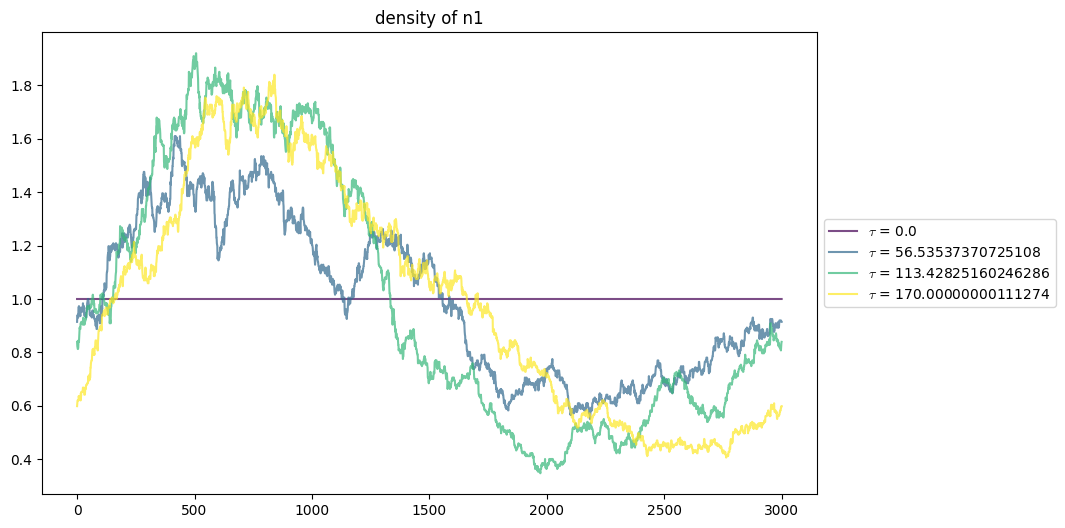

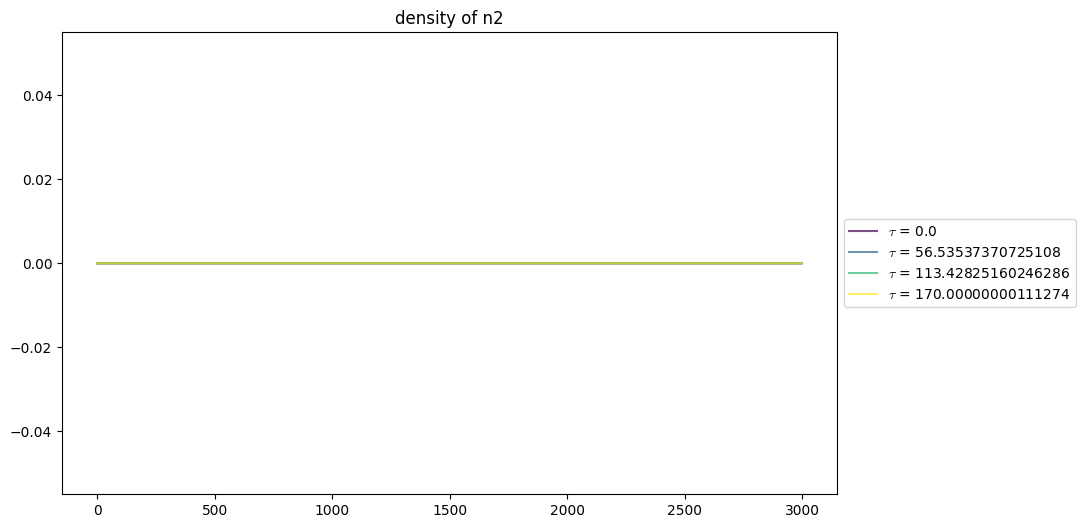

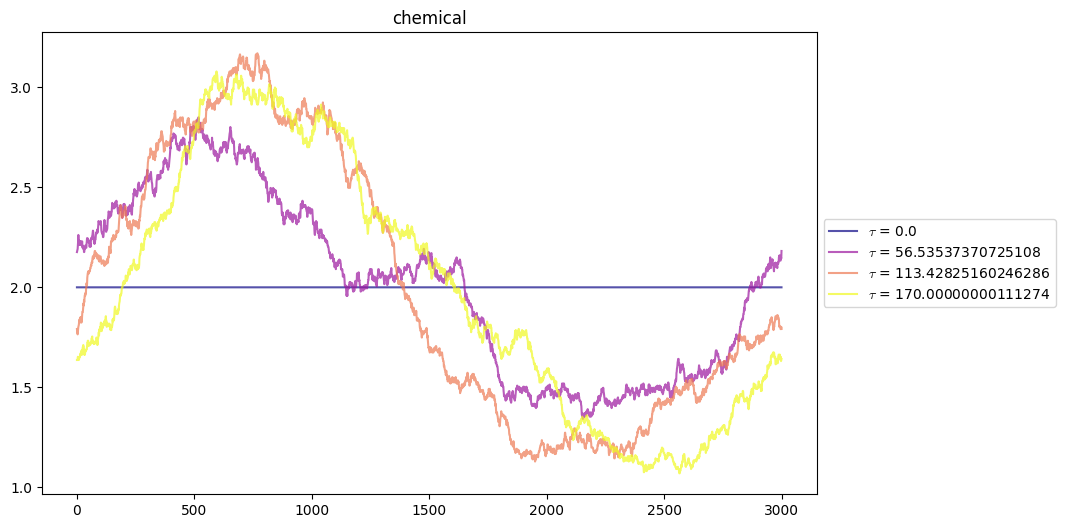

In [67]:
from helper_functions import *
# path = files[8]
path = 'cluster_data/05jun/3.00/1.00'
print(path)
occupancies_t, tau_t, _, _, _ = load_sim(path)
w = int(occupancies_t.shape[2]) // 32

print(w)
plot_results(occupancies_t, tau_t, w, 0, 1, 4)

In [2]:
N = 150
maxima = np.zeros(N)

for i in range(N):
    maxima[i] = np.max(meso_avg(occupancies_t[-1,0,:], i))

Text(0.5, 1.0, 'Convergence of hydrodynamic limit (max peak height wrt average window size)')

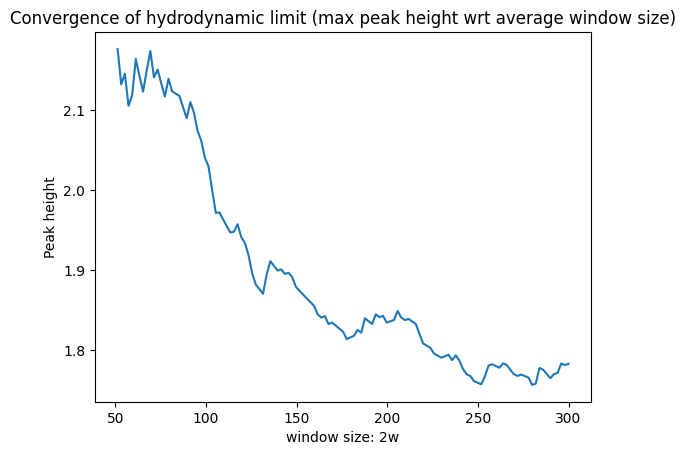

In [3]:
plt.plot(np.linspace(1, N * 2, N)[25:], maxima[25:])
plt.xlabel('window size: 2w')
plt.ylabel('Peak height')
plt.title('Convergence of hydrodynamic limit (max peak height wrt average window size)')

In [4]:
np.mean(occupancies_t[-1, 0:]), np.var(occupancies_t[-1, 0,:])

(np.float64(0.9968888888888889), np.float64(2.354))

(888, 3, 3000)

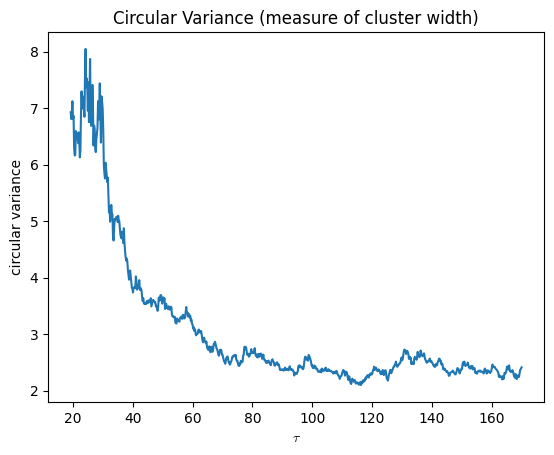

In [10]:
Nsites = occupancies_t.shape[2]

discrete_wave = np.array([np.exp((2 * np.pi / occupancies_t.shape[2]) * i * 1j) for i in range(occupancies_t.shape[2])])

product =  discrete_wave * occupancies_t[:, 0, :]
m1 = np.sum(product, axis=1) / np.sum(occupancies_t[:, 0, :], axis=1)
circle_variances = -2 * np.log(np.abs(m1))
plt.plot(tau_t[100:], circle_variances[100:])
plt.xlabel(fr'$\tau$')
plt.ylabel('circular variance')
plt.title('Circular Variance (measure of cluster width)')
occupancies_t.shape

In [57]:
s = 0.95
e = 1
Nt = occupancies_t.shape[0]
rho = occupancies_t[int(Nt*s):int(Nt*e), 0, :]

_, L = rho.shape

print(rho.shape)

rho_centered = np.empty_like(rho)

for i in range(rho.shape[0]):
    peak = np.argmax(rho[i])
    shift = L // 2 - peak
    rho_centered[i] = np.roll(rho[i], shift)

rho = rho_centered

# remove DC mode per run (crucial)
rho_fluct = rho - rho.mean(axis=1, keepdims=True)

rhok = np.fft.fft(rho_fluct, axis=1)

#structure factor
Sk = np.mean(np.abs(rhok)**2, axis=0) / L**2

ks = np.fft.fftshift(2*np.pi*np.fft.fftfreq(L))
Sk = np.fft.fftshift(Sk)

Sk_norm = Sk / Sk.max()

above = np.where(Sk_norm >= 0.5)[0]

fwhm_k = ks[above[-1]] - ks[above[0]]
xi = 2*np.pi / fwhm_k
xi

(45, 3000)


np.float64(1500.0000000000002)

In [28]:
ks = 2 * np.pi * np.fft.fftfreq(L)

print("S(0) =", Sk[0])
print("mean S(k>0) =", np.mean(Sk[1:]))
print("max S(k>0) =", np.max(Sk[1:]))

S(0) = 0.0006094814814814815
mean S(k>0) = 0.0008342576414360343
max S(k>0) = 0.0994710986689093


Using ornstein zernicke fit:

In [31]:
rho_fluct = rho - rho.mean(axis=1, keepdims=True)

rhok = np.fft.fft(rho_fluct, axis=1)
Sk = np.mean(np.abs(rhok)**2, axis=0) / L

ks = 2 * np.pi * np.fft.fftfreq(L)

# center both consistently
ks = np.fft.fftshift(ks)
Sk = np.fft.fftshift(Sk)

# FWHM
Sk_norm = Sk / Sk.max()
above = np.where(Sk_norm >= 0.5)[0]

fwhm_k = ks[above[-1]] - ks[above[0]]
xi = np.sqrt(-np.polyfit(ks[ks>0][:5]**2, Sk[ks>0][:5]/Sk.max(), 1)[0])
print("xi =", xi)

xi = 78.99881599822926


Structure factor with diagnostics

k_peak = 0.0020943951023931952
correlation length ξ ≈ nan
>>> No finite-k peak → homogeneous or critical fluctuations
high-k slope ≈ -0.48506299669117514


/var/folders/tw/wwds8prs35n99xx6b_5911sh0000gn/T/ipykernel_31297/3853833741.py:41: RuntimeWarning: invalid value encountered in sqrt
  xi = np.sqrt(coef[0])


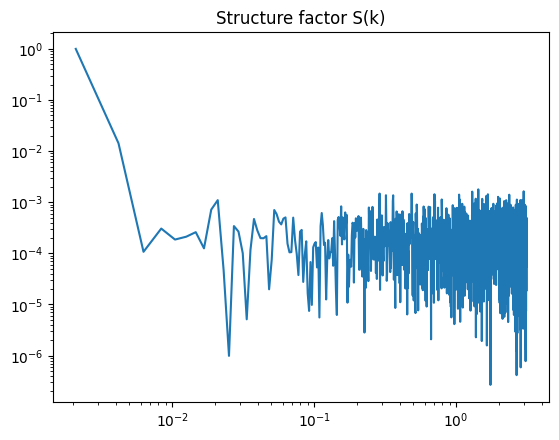

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# --- FFT ---
rho_fluct = rho - rho.mean(axis=1, keepdims=True)
rho_mean = np.mean(rho_fluct, axis=0)
rho_mean[np.argmax(rho_mean)] = 0

rhok = np.fft.fft(rho_mean)
Sk = np.abs(rhok)**2 / rho.shape[1]

ks = 2*np.pi*np.fft.fftfreq(rho.shape[1])

# --- remove k=0 for physics ---
mask = ks > 0
k = ks[mask]
S = Sk[mask]

# --- reorder for plotting ---
idx = np.argsort(k)
k = k[idx]
S = S[idx]

# --- normalize for shape analysis ---
S_norm = S / S.max()

# =========================================================
# 1. FIND PEAK POSITION (detect phase separation signature)
# =========================================================
k_peak = k[np.argmax(S)]

print("k_peak =", k_peak)

# =========================================================
# 2. SMALL-k FIT (hydrodynamic regime)
# S(k) ≈ A / (1 + ξ² k²)
# =========================================================
fit_mask = k < 0.1 * np.max(k)

coef = np.polyfit(k[fit_mask]**2, 1/S[fit_mask], 1)
xi = np.sqrt(coef[0])

print("correlation length ξ ≈", xi)

# =========================================================
# 3. CHECK FOR PHASE SEPARATION
# =========================================================
if k_peak > 0.1 * np.max(k):
    print(">>> Finite-k peak detected → phase separation / pattern formation likely")
else:
    print(">>> No finite-k peak → homogeneous or critical fluctuations")

# =========================================================
# 4. POROD LAW CHECK (high-k tail)
# S(k) ~ k^{-n}
# =========================================================
highk = k > 0.5 * np.max(k)

logk = np.log(k[highk])
logS = np.log(S[highk])

slope = np.polyfit(logk, logS, 1)[0]

print("high-k slope ≈", slope)

# =========================================================
# 5. PLOTS
# =========================================================
plt.figure()
plt.plot(k, S_norm)
plt.xscale("log")
plt.yscale("log")
plt.title("Structure factor S(k)")
plt.show()

Bare rho average

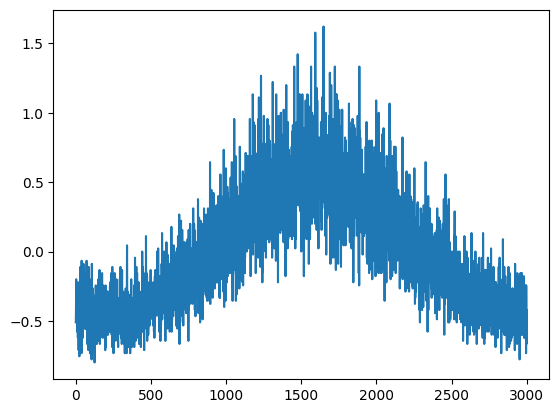

In [41]:
rho_mean = np.mean(rho_fluct, axis=0)
rho_mean[np.argmax(rho_mean)] = 0

plt.plot(rho_mean)

bare rhok (from bare average)

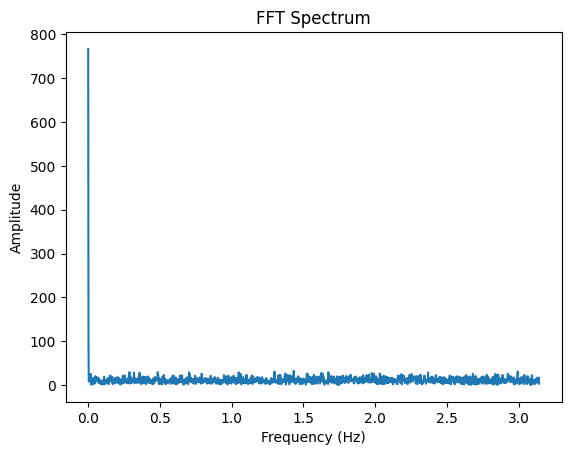

In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Example signal: sum of two sine waves
t = np.linspace(0, 1, 1000, endpoint=False)
f = np.sin(2*np.pi*50*t) + 0.5*np.sin(2*np.pi*120*t)

# Compute FFT
F = np.fft.fft(rho_mean)

# Frequency axis
freqs = np.fft.fftfreq(3000, d=0.5/np.pi)

# Take only positive frequencies
mask = freqs > 0

plt.plot(freqs[mask], np.abs(F)[mask])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT Spectrum")
plt.show()